In [42]:
# ============================
# STEP 1. Imports
# ============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pretty display
pd.set_option("display.max_columns", None)

# ============================
# STEP 2. Load Data
# ============================
train = pd.read_csv("/kaggle/input/predicting-data-camp-courses-rating/train.csv")
test = pd.read_csv("/kaggle/input/predicting-data-camp-courses-rating/test.csv")
train.head()







,id,title,programming_language,difficulty_level,xp,time_needed_in_hours,topic_id,technology_id,content_area,nb_of_subscriptions,num_chapters,num_exercises,num_videos,datasets_count,difficulty_score,course_rating
0,16,Large Language Models (LLMs) Concepts,r,1,3300,2,16.0,7,Artificial Intelligence,66747,4,50,15,0,3.0,2.05
1,69,Introduction to Deep Learning in Python,python,2,3500,4,16.0,2,Artificial Intelligence,258161,4,50,17,3,3.0,2.38
2,32,Working with Hugging Face,python,1,2050,2,16.0,2,Artificial Intelligence,16188,2,26,8,4,3.0,2.18
3,25,Cleaning Data in Python,python,2,3500,4,18.0,2,Data Science and Analytics,140166,4,44,13,5,3.0,1.99
4,56,Linear Classifiers in Python,python,2,3200,4,6.0,2,Data Science and Analytics,61497,4,44,13,0,3.0,2.38


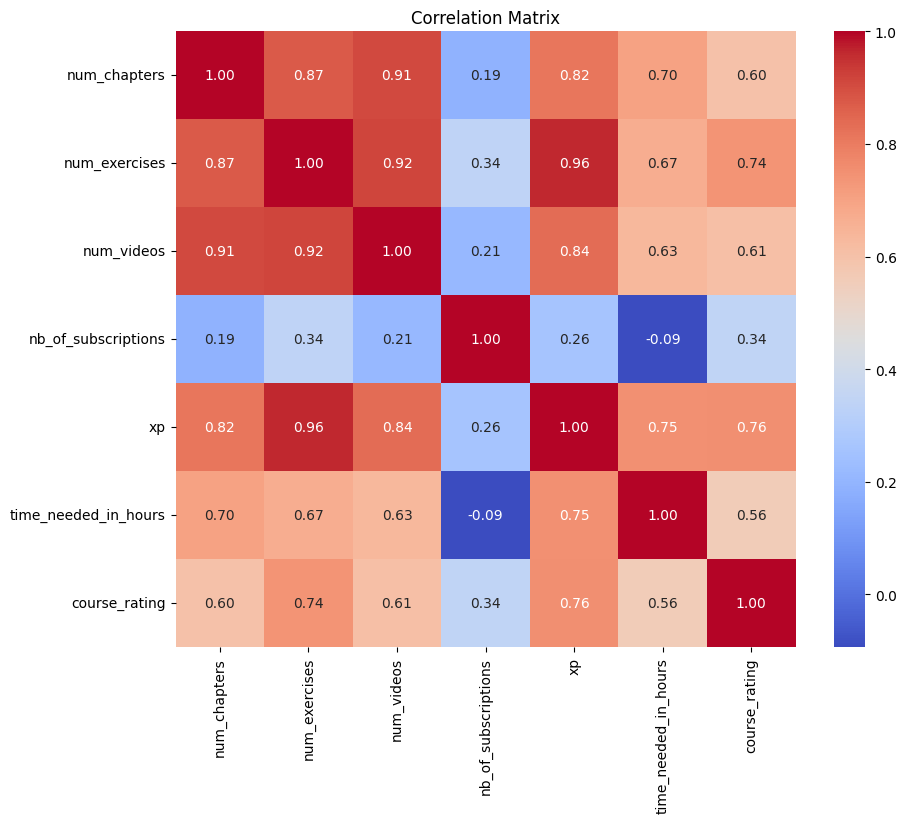

In [9]:
# Correlation Matrix
plt.figure(figsize=(10,8))
corr_matrix = train[num_cols + [target]].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix")
plt.show()


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import lightgbm as lgb
import xgboost as xgb
import warnings

# Suppress warnings for a cleaner output
warnings.filterwarnings('ignore')

# =======================
# Load Data
# =======================
try:
    # Using local file paths
    train_df = pd.read_csv("/kaggle/input/predicting-data-camp-courses-rating/train.csv")
    test_df = pd.read_csv("/kaggle/input/predicting-data-camp-courses-rating/test.csv")
except FileNotFoundError as e:
    print(f"Error loading data: {e}")
    print("Please make sure 'train.csv' and 'test.csv' are in the same directory as the script.")
    exit()

# Keep test IDs for submission
test_ids = test_df["id"]

# =======================
# Feature Engineering
# =======================
def create_features(df):
    """Engineers new features from the existing data."""
    df_copy = df.copy()
    # Create ratio features, adding a small epsilon to avoid division by zero
    df_copy['xp_per_hour'] = df_copy['xp'] / (df_copy['time_needed_in_hours'] + 1e-6)
    df_copy['exercises_per_chapter'] = df_copy['num_exercises'] / (df_copy['num_chapters'] + 1e-6)
    df_copy['videos_per_chapter'] = df_copy['num_videos'] / (df_copy['num_chapters'] + 1e-6)
    
    # Create interaction/combination features
    df_copy['total_content_items'] = df_copy['num_exercises'] + df_copy['num_videos'] + df_copy['datasets_count']
    
    return df_copy

print("Creating new features...")
train_df = create_features(train_df)
test_df = create_features(test_df)

# =======================
# Define Target and Features
# =======================
y = train_df["course_rating"]

# Use original numeric features and the new engineered features
features = [
    "nb_of_subscriptions",'xp_per_hour', 'exercises_per_chapter', 'videos_per_chapter', 'total_content_items'

]

X = train_df[features]
test = test_df[features]

# =======================
# Define Models to Evaluate
# =======================
models = {
    "Ridge": Ridge(random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "LGBM": lgb.LGBMRegressor(random_state=42, verbose=-1),
    "XGBoost": xgb.XGBRegressor(random_state=42)
}

# =======================
# Evaluate Models using Cross-Validation
# =======================
results = {}
cv = KFold(n_splits=10, shuffle=True, random_state=42)

print("Evaluating models with new features...")
for name, model in models.items():
    # Create a pipeline with a scaler and the model
    pipeline = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    # Perform cross-validation
    scores = -cross_val_score(pipeline, X, y,
                              scoring="neg_root_mean_squared_error",
                              cv=cv, n_jobs=-1)
    
    results[name] = scores
    print(f"{name} CV RMSE: {scores.mean():.4f} (+/- {scores.std():.4f})")

# =======================
# Select the Best Model
# =======================
best_model_name = min(results, key=lambda name: np.mean(results[name]))
best_model = models[best_model_name]
print(f"\nBest model selected: {best_model_name} with RMSE: {np.mean(results[best_model_name]):.4f}")

# =======================
# Train Best Model on Full Data and Predict
# =======================
print(f"Training {best_model_name} on the full dataset...")

# Create the final pipeline with the best model
final_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', best_model)
])

# Train the pipeline
final_pipeline.fit(X, y)

# Make predictions on the test set
final_predictions = final_pipeline.predict(test)

# =======================
# Submission
# =======================
submission = pd.DataFrame({
    "id": test_ids,
    "course_rating": final_predictions.round(2)
})
submission.to_csv("submission.csv", index=False)

print("\n✅ Submission file saved as submission.csv")

Creating new features...
Evaluating models with new features...
Ridge CV RMSE: 0.2882 (+/- 0.0689)
RandomForest CV RMSE: 0.3219 (+/- 0.0854)
GradientBoosting CV RMSE: 0.3269 (+/- 0.0807)
LGBM CV RMSE: 0.3321 (+/- 0.0882)
XGBoost CV RMSE: 0.3600 (+/- 0.1083)

Best model selected: Ridge with RMSE: 0.2882
Training Ridge on the full dataset...

✅ Submission file saved as submission.csv


In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import lightgbm as lgb
import xgboost as xgb
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings

warnings.filterwarnings('ignore')

# =======================
# Load Data
# =======================
train_df = pd.read_csv("/kaggle/input/predicting-data-camp-courses-rating/train.csv")
test_df = pd.read_csv("/kaggle/input/predicting-data-camp-courses-rating/test.csv")
test_ids = test_df["id"]

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

# =======================
# Enhanced Feature Engineering
# =======================
def create_features(df):
    """Engineers comprehensive features from the data."""
    df_copy = df.copy()
    
    # === Ratio Features ===
    df_copy['xp_per_hour'] = df_copy['xp'] / (df_copy['time_needed_in_hours'] + 1e-6)
    df_copy['xp_per_chapter'] = df_copy['xp'] / (df_copy['num_chapters'] + 1e-6)
    df_copy['exercises_per_chapter'] = df_copy['num_exercises'] / (df_copy['num_chapters'] + 1e-6)
    df_copy['videos_per_chapter'] = df_copy['num_videos'] / (df_copy['num_chapters'] + 1e-6)
    df_copy['datasets_per_chapter'] = df_copy['datasets_count'] / (df_copy['num_chapters'] + 1e-6)
    
    # Time-based ratios
    df_copy['exercises_per_hour'] = df_copy['num_exercises'] / (df_copy['time_needed_in_hours'] + 1e-6)
    df_copy['videos_per_hour'] = df_copy['num_videos'] / (df_copy['time_needed_in_hours'] + 1e-6)
    df_copy['content_per_hour'] = (df_copy['num_exercises'] + df_copy['num_videos']) / (df_copy['time_needed_in_hours'] + 1e-6)
    
    # === Interaction Features ===
    df_copy['total_content_items'] = df_copy['num_exercises'] + df_copy['num_videos'] + df_copy['datasets_count']
    df_copy['content_density'] = df_copy['total_content_items'] / (df_copy['num_chapters'] + 1e-6)
    df_copy['exercise_video_ratio'] = df_copy['num_exercises'] / (df_copy['num_videos'] + 1e-6)
    
    # Popularity metrics
    df_copy['subscriptions_log'] = np.log1p(df_copy['nb_of_subscriptions'])
    df_copy['subscriptions_per_chapter'] = df_copy['nb_of_subscriptions'] / (df_copy['num_chapters'] + 1e-6)
    
    # === Polynomial Features ===
    df_copy['num_chapters_squared'] = df_copy['num_chapters'] ** 2
    df_copy['time_squared'] = df_copy['time_needed_in_hours'] ** 2
    df_copy['difficulty_score_squared'] = df_copy['difficulty_score'] ** 2
    
    # === Text Features ===
    df_copy['title_length'] = df_copy['title'].fillna('').str.len()
    df_copy['title_word_count'] = df_copy['title'].fillna('').str.split().str.len()
    
    # Combined text for TF-IDF
    df_copy['combined_text'] = df_copy['title'].fillna('')
    
    # Fill missing values in categorical columns
    for col in ['programming_language', 'difficulty_level']:
        if col in df_copy.columns:
            df_copy[col] = df_copy[col].fillna('Unknown')
    
    return df_copy

print("\nCreating enhanced features...")
train_df = create_features(train_df)
test_df = create_features(test_df)

# =======================
# Text Vectorization (TF-IDF)
# =======================
print("Vectorizing text features...")
tfidf = TfidfVectorizer(
    max_features=30, 
    stop_words='english', 
    ngram_range=(1, 2),
    min_df=2
)

train_text_features = tfidf.fit_transform(train_df['combined_text'])
test_text_features = tfidf.transform(test_df['combined_text'])

train_text_df = pd.DataFrame(
    train_text_features.toarray(), 
    columns=[f'tfidf_{i}' for i in range(train_text_features.shape[1])]
)
test_text_df = pd.DataFrame(
    test_text_features.toarray(), 
    columns=[f'tfidf_{i}' for i in range(test_text_features.shape[1])]
)

# =======================
# Categorical Encoding
# =======================
print("Encoding categorical features...")
categorical_features = ['programming_language', 'difficulty_level']

train_encoded = pd.get_dummies(train_df[categorical_features], drop_first=False)
test_encoded = pd.get_dummies(test_df[categorical_features], drop_first=False)

# Align columns between train and test
train_encoded, test_encoded = train_encoded.align(test_encoded, join='left', axis=1, fill_value=0)

# =======================
# Numeric Features
# =======================
numeric_features = [
    # Original features
    'xp', 'time_needed_in_hours', 'topic_id', 'technology_id',
    'nb_of_subscriptions'
    
    # Engineered ratio features
    'xp_per_hour', 'xp_per_chapter', 'exercises_per_chapter', 'videos_per_chapter',
    'datasets_per_chapter', 'exercises_per_hour', 'videos_per_hour', 'content_per_hour',
    
    # Interaction features
    'total_content_items', 'content_density', 'exercise_video_ratio',
    'subscriptions_log', 'subscriptions_per_chapter',
    
    # Polynomial features
    'num_chapters_squared', 'time_squared', 'difficulty_score_squared',
    
    # Text features
    'title_length', 'title_word_count'
]

# =======================
# Combine All Features
# =======================
y = train_df["course_rating"]

X_numeric = train_df[numeric_features].fillna(0).replace([np.inf, -np.inf], 0)
test_numeric = test_df[numeric_features].fillna(0).replace([np.inf, -np.inf], 0)

X_combined = pd.concat([
    X_numeric.reset_index(drop=True),
    train_encoded.reset_index(drop=True),
    train_text_df.reset_index(drop=True)
], axis=1)

test_combined = pd.concat([
    test_numeric.reset_index(drop=True),
    test_encoded.reset_index(drop=True),
    test_text_df.reset_index(drop=True)
], axis=1)

print(f"\n✅ Total features: {X_combined.shape[1]}")
print(f"   - Numeric: {len(numeric_features)}")
print(f"   - Categorical (one-hot): {train_encoded.shape[1]}")
print(f"   - Text (TF-IDF): {train_text_df.shape[1]}")

# =======================
# Model Evaluation
# =======================
models = {
    "Ridge": Ridge(alpha=5, random_state=42),
    "RandomForest": RandomForestRegressor(
        n_estimators=500, 
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42, 
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        min_samples_split=5,
        random_state=42
    ),
    "LGBM": lgb.LGBMRegressor(
        n_estimators=600,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=8,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1
    ),
    "XGBoost": xgb.XGBRegressor(
        n_estimators=600,
        learning_rate=0.03,
        max_depth=7,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        tree_method='hist'
    )
}

results = {}
cv = KFold(n_splits=10, shuffle=True, random_state=42)

print("\n" + "="*50)
print("EVALUATING MODELS")
print("="*50)

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    scores = -cross_val_score(
        pipeline, X_combined, y,
        scoring="neg_root_mean_squared_error",
        cv=cv, 
        n_jobs=-1
    )
    
    results[name] = scores
    print(f"{name:20s} RMSE: {scores.mean():.5f} (+/- {scores.std():.5f})")

# =======================
# Train Best Model
# =======================
best_model_name = min(results, key=lambda name: np.mean(results[name]))
best_model = models[best_model_name]

print("\n" + "="*50)
print(f"✅ BEST MODEL: {best_model_name}")
print(f"   CV RMSE: {np.mean(results[best_model_name]):.5f}")
print("="*50)

# Train on full data
final_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model', best_model)
])

print(f"\nTraining {best_model_name} on full dataset...")
final_pipeline.fit(X_combined, y)

# Make predictions
final_predictions = final_pipeline.predict(test_combined)

# Clip predictions to valid rating range [0, 5]
final_predictions = np.clip(final_predictions, 0, 5)

# =======================
# Submission
# =======================
submission = pd.DataFrame({
    "id": test_ids,
    "course_rating": final_predictions.round(2)
})

submission.to_csv("submission.csv", index=False)

print("\n✅ Submission file saved as submission.csv")
print(f"   Predictions range: [{final_predictions.min():.2f}, {final_predictions.max():.2f}]")
print(f"   Mean prediction: {final_predictions.mean():.2f}")

Train shape: (92, 16)
Test shape: (24, 15)

Creating enhanced features...
Vectorizing text features...
Encoding categorical features...


KeyError: "['nb_of_subscriptionsxp_per_hour'] not in index"

In [3]:
# ==========================
# 📌 Full ML Pipeline (Linear Models Only)
# ==========================
import pandas as pd
import numpy as np

from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

# Linear models
from sklearn.linear_model import Ridge, Lasso, ElasticNet, SGDRegressor

# ==========================
# 1. Load Data
# ==========================
train_df = pd.read_csv("/kaggle/input/predicting-data-camp-courses-rating/train.csv")
test_df = pd.read_csv("/kaggle/input/predicting-data-camp-courses-rating/test.csv")
test_ids = test_df["id"]

# ==========================
# 2. Feature Engineering
# ==========================
def create_features(df):
    df_copy = df.copy()
    df_copy['xp_per_hour'] = df_copy['xp'] / (df_copy['time_needed_in_hours'] + 1e-6)
    df_copy['exercises_per_chapter'] = df_copy['num_exercises'] / (df_copy['num_chapters'] + 1e-6)
    df_copy['videos_per_chapter'] = df_copy['num_videos'] / (df_copy['num_chapters'] + 1e-6)
    df_copy['total_content_items'] = df_copy['num_exercises'] + df_copy['num_videos'] + df_copy['datasets_count']
    return df_copy

train_df = create_features(train_df)
test_df = create_features(test_df)

# ==========================
# 3. Tabular Features
# ==========================
numeric_features = [
    "xp", "time_needed_in_hours", "num_chapters", "num_exercises", 
    "num_videos", "datasets_count",
     "difficulty_score", "nb_of_subscriptions",
    "xp_per_hour", "exercises_per_chapter", "videos_per_chapter", "total_content_items"
]
categorical_features = ["programming_language", "content_area", "difficulty_level"]

X_tab = train_df[numeric_features + categorical_features]
X_test_tab = test_df[numeric_features + categorical_features]
y = train_df["course_rating"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

# ==========================
# 4. Text Features (TF-IDF)
# ==========================
train_text = train_df["title"].fillna("")
test_text = test_df["title"].fillna("")

tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1,2))
X_text = tfidf.fit_transform(train_text)
X_test_text = tfidf.transform(test_text)

# ==========================
# 5. Candidate Linear Models
# ==========================
tabular_models = {
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "Lasso": Lasso(alpha=0.001, random_state=42, max_iter=5000),
    "ElasticNet": ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=42, max_iter=5000),
    "SGDRegressor": SGDRegressor(loss="squared_error", penalty="elasticnet", 
                                 alpha=0.0005, l1_ratio=0.15, max_iter=3000, random_state=42)
}

# Text model — Ridge works very well on TF-IDF
text_model = Ridge(alpha=1.0, random_state=42, solver="lsqr")

# ==========================
# 6. Cross-validation for Tabular Models
# ==========================
cv = KFold(n_splits=10, shuffle=True, random_state=42)
tabular_results = {}

print("\n📊 Evaluating Tabular Models with CV:")
for name, model in tabular_models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    scores = -cross_val_score(pipe, X_tab, y, 
                              scoring="neg_root_mean_squared_error", cv=cv, n_jobs=-1)
    tabular_results[name] = (scores.mean(), scores.std())
    print(f"{name:12s} RMSE: {scores.mean():.4f} (+/- {scores.std():.4f})")

# ==========================
# 7. Cross-validation for Text Model
# ==========================
scores_text = -cross_val_score(text_model, X_text, y, 
                               scoring="neg_root_mean_squared_error", cv=cv, n_jobs=-1)
print(f"\nText (Ridge) RMSE: {scores_text.mean():.4f} (+/- {scores_text.std():.4f})")

# ==========================
# 8. Train Final Models
# ==========================
best_tab_model_name = min(tabular_results, key=lambda k: tabular_results[k][0])
print(f"\n✅ Best Tabular Model: {best_tab_model_name}")

best_tab_model = tabular_models[best_tab_model_name]
tabular_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_tab_model)
])

tabular_pipeline.fit(X_tab, y)
text_model.fit(X_text, y)

# ==========================
# 9. Predictions & Blending
# ==========================
pred_tabular = tabular_pipeline.predict(X_test_tab)
pred_text = text_model.predict(X_test_text)

# Blend predictions
final_predictions = 0.6 * pred_tabular + 0.4 * pred_text
final_predictions = final_predictions.clip(1.0, 5.0)

# ==========================
# 10. Submission
# ==========================
submission = pd.DataFrame({
    "id": test_ids,
    "course_rating": final_predictions.round(2)
})
submission.to_csv("submission.csv", index=False)
print("\n🚀 Submission file saved as submission.csv")
#f real submission pred_text means something
#DROP didnt make a huge diff ( from 0.007 to 0.009)


📊 Evaluating Tabular Models with CV:
Ridge        RMSE: 0.2875 (+/- 0.0571)
Lasso        RMSE: 0.2875 (+/- 0.0564)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.341e-03, tolerance: 1.733e-03
  model = cd_fast.enet_coordinate_descent(


ElasticNet   RMSE: 0.2918 (+/- 0.0576)
SGDRegressor RMSE: 0.3221 (+/- 0.0627)

Text (Ridge) RMSE: 0.4272 (+/- 0.0740)

✅ Best Tabular Model: Ridge

🚀 Submission file saved as submission.csv


In [2]:
# ==========================
# 📌 Full ML Pipeline with GridSearch
# ==========================
import pandas as pd
import numpy as np

from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

# Linear models
from sklearn.linear_model import Ridge, Lasso, ElasticNet, SGDRegressor

# ==========================
# 1. Load Data
# ==========================
train_df = pd.read_csv("/kaggle/input/predicting-data-camp-courses-rating/train.csv")
test_df = pd.read_csv("/kaggle/input/predicting-data-camp-courses-rating/test.csv")
test_ids = test_df["id"]

# ==========================
# 2. Feature Engineering
# ==========================
def create_features(df):
    df_copy = df.copy()
    df_copy['xp_per_hour'] = df_copy['xp'] / (df_copy['time_needed_in_hours'] + 1e-6)
    df_copy['exercises_per_chapter'] = df_copy['num_exercises'] / (df_copy['num_chapters'] + 1e-6)
    df_copy['videos_per_chapter'] = df_copy['num_videos'] / (df_copy['num_chapters'] + 1e-6)
    df_copy['total_content_items'] = df_copy['num_exercises'] + df_copy['num_videos'] + df_copy['datasets_count']
    return df_copy

train_df = create_features(train_df)
test_df = create_features(test_df)

# ==========================
# 3. Tabular Features
# ==========================
numeric_features = [
    "xp", "time_needed_in_hours", "num_chapters", "num_exercises", 
    "num_videos", "datasets_count", "difficulty_score", "nb_of_subscriptions",
    "xp_per_hour", "exercises_per_chapter", "videos_per_chapter", 
    "total_content_items"
]
categorical_features = ["content_area","programming_language",  "difficulty_level"]

X_tab = train_df[numeric_features + categorical_features]
X_test_tab = test_df[numeric_features + categorical_features]
y = train_df["course_rating"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

# ==========================
# 4. Text Features (TF-IDF)
# ==========================
train_text = train_df["title"].fillna("")
test_text = test_df["title"].fillna("")

# train_text=train_df["title"].fillna("")
# test_text=test_df["title"].fillna("")

tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1,2))
X_text = tfidf.fit_transform(train_text)
X_test_text = tfidf.transform(test_text)

# ==========================
# 5. GridSearch on Linear Models
# ==========================
cv = KFold(n_splits=10, shuffle=True, random_state=42)

param_grids = {
    "Ridge": {"model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]},
    "Lasso": {"model__alpha": [0.0001, 0.001, 0.01, 0.1, 1]},
    "ElasticNet": {
        "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1],
        "model__l1_ratio": [0.2, 0.5, 0.7, 0.9]
    }
}

base_models = {
    "Ridge": Ridge(random_state=42, solver="lsqr"),
    "Lasso": Lasso(random_state=42, max_iter=5000),
    "ElasticNet": ElasticNet(random_state=42, max_iter=5000)
}

best_models = {}
print("\n🔍 Running GridSearch for Linear Models...\n")

for name, model in base_models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    grid = GridSearchCV(pipe, param_grids[name], cv=cv,
                        scoring="neg_root_mean_squared_error", n_jobs=-1)
    grid.fit(X_tab, y)
    print(f"{name} best params: {grid.best_params_} | RMSE: {-grid.best_score_:.4f}")
    best_models[name] = grid.best_estimator_

# ==========================
# 6. Text Model (Ridge TF-IDF)
# ==========================
text_model = Ridge(alpha=1.0, random_state=42, solver="lsqr")
scores_text = -cross_val_score(text_model, X_text, y,
                               scoring="neg_root_mean_squared_error", cv=cv, n_jobs=-1)
print(f"\nText (Ridge) RMSE: {scores_text.mean():.4f} (+/- {scores_text.std():.4f})")
text_model.fit(X_text, y)

# ==========================
# 7. Predictions & Blending
# ==========================
# Choose the best tabular model from gridsearch
best_tab_name = min(best_models, key=lambda k: 
                    -cross_val_score(best_models[k], X_tab, y,
                                     scoring="neg_root_mean_squared_error", 
                                     cv=cv, n_jobs=-1).mean())
print(f"\n✅ Best Tabular Model: {best_tab_name}")

best_tab_model = best_models[best_tab_name]

# Predictions
pred_tabular = best_tab_model.predict(X_test_tab)
pred_text = text_model.predict(X_test_text)

# Blend predictions (weight can be tuned)
final_predictions = 0.6 * pred_tabular + 0.4 * pred_text
final_predictions = final_predictions.clip(1.0, 5.0)

# ==========================
# 8. Submission
# ==========================
submission = pd.DataFrame({
    "id": test_ids,
    "course_rating": final_predictions.round(2)
})
submission.to_csv("submission.csv", index=False)
print("\n🚀 Submission file saved as submission.csv")



🔍 Running GridSearch for Linear Models...

Ridge best params: {'model__alpha': 10} | RMSE: 0.2777


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.865e-02, tolerance: 1.592e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.249e-03, tolerance: 1.579e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.636e-02, tolerance: 1.675e

Lasso best params: {'model__alpha': 0.001} | RMSE: 0.2875


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.503e-01, tolerance: 1.592e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.654e-02, tolerance: 1.620e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.979e-01, tolerance: 1.675e

ElasticNet best params: {'model__alpha': 0.01, 'model__l1_ratio': 0.2} | RMSE: 0.2814

Text (Ridge) RMSE: 0.4272 (+/- 0.0740)

✅ Best Tabular Model: Ridge

🚀 Submission file saved as submission.csv


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.341e-03, tolerance: 1.733e-03
  model = cd_fast.enet_coordinate_descent(


In [32]:
# ==========================
# 📌 Full ML Pipeline with Text Model Enhancements
# ==========================
import pandas as pd
import numpy as np

from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# ==========================
# 1. Load Data
# ==========================
train_df = pd.read_csv("/kaggle/input/predicting-data-camp-courses-rating/train.csv")
test_df = pd.read_csv("/kaggle/input/predicting-data-camp-courses-rating/test.csv")
test_ids = test_df["id"]

# ==========================
# 2. Feature Engineering
# ==========================
def create_features(df):
    df_copy = df.copy()
    df_copy['xp_per_hour'] = df_copy['xp'] / (df_copy['time_needed_in_hours'] + 1e-6)
    df_copy['exercises_per_chapter'] = df_copy['num_exercises'] / (df_copy['num_chapters'] + 1e-6)
    df_copy['videos_per_chapter'] = df_copy['num_videos'] / (df_copy['num_chapters'] + 1e-6)
    df_copy['total_content_items'] = df_copy['num_exercises'] + df_copy['num_videos'] + df_copy['datasets_count']
    
    return df_copy

train_df = create_features(train_df)
test_df = create_features(test_df)

# ==========================
# 3. Tabular Features
# ==========================
numeric_features = [
    "xp", "time_needed_in_hours", "num_chapters", "num_exercises", 
    "num_videos", "datasets_count", "difficulty_score", "nb_of_subscriptions",
    "xp_per_hour", "exercises_per_chapter", "videos_per_chapter", 
    "total_content_items"
]
categorical_features = ["content_area","programming_language", "difficulty_level"]

X_tab = train_df[numeric_features + categorical_features]
X_test_tab = test_df[numeric_features + categorical_features]
y = train_df["course_rating"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=1), categorical_features)
])

# ==========================
# 4. Text Features
# ==========================
train_text = train_df["title"].fillna("")
test_text = test_df["title"].fillna("")

# ==========================
# 5. GridSearch on Linear Models (Tabular)
# ==========================
cv = KFold(n_splits=15, shuffle=True, random_state=42)

param_grids = {
    "Ridge": {"model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]},
    "Lasso": {"model__alpha": [0.0001, 0.001, 0.01, 0.1, 1]},
    "ElasticNet": {
        "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1],
        "model__l1_ratio": [0.2, 0.5, 0.7, 0.9]
    }
}

base_models = {
    "Ridge": Ridge(random_state=42, solver="lsqr"),
    "Lasso": Lasso(random_state=42, max_iter=5000),
    "ElasticNet": ElasticNet(random_state=42, max_iter=5000)
}

best_models = {}
print("\n🔍 Running GridSearch for Linear Models...\n")
for name, model in base_models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    grid = GridSearchCV(pipe, param_grids[name], cv=cv,
                        scoring="neg_root_mean_squared_error", n_jobs=-1)
    grid.fit(X_tab, y)
    print(f"{name} best params: {grid.best_params_} | RMSE: {-grid.best_score_:.4f}")
    best_models[name] = grid.best_estimator_

# ==========================
# 6. Enhanced Text Model (Ridge with GridSearch)
# ==========================
text_pipe = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("model", Ridge(random_state=42, solver="lsqr"))
])

text_param_grid = {
    "tfidf__max_features": [5000, 8000, 12000],
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__min_df": [1, 2, 5],
    "tfidf__max_df": [0.8, 0.9, 1.0],
    "model__alpha": [0.1, 1.0, 10.0]
}

grid_text = GridSearchCV(text_pipe, text_param_grid, cv=cv,
                         scoring="neg_root_mean_squared_error", n_jobs=-1)
grid_text.fit(train_text, y)

print(f"\nBest Text Model Params: {grid_text.best_params_} | RMSE: {-grid_text.best_score_:.4f}")
best_text_model = grid_text.best_estimator_

# ==========================
# 7. Predictions & Blending
# ==========================
best_tab_name = min(best_models, key=lambda k: 
                    -cross_val_score(best_models[k], X_tab, y,
                                     scoring="neg_root_mean_squared_error", 
                                     cv=cv, n_jobs=-1).mean())
print(f"\n✅ Best Tabular Model: {best_tab_name}")

best_tab_model = best_models[best_tab_name]

pred_tabular = best_tab_model.predict(X_test_tab)
pred_text = best_text_model.predict(test_text)

# Blend predictions
final_predictions = 0.45 * pred_tabular + 0.55 * pred_text
final_predictions = final_predictions.clip(1.0, 5.0)

# ==========================
# 8. Submission
# ==========================
submission = pd.DataFrame({
    "id": test_ids,
    "course_rating": final_predictions.round(2)
})
submission.to_csv("submission.csv", index=False)
print("\n🚀 Submission file saved as submission.csv")
#best score i ve got is with 0.45 tab and 0.55 text , so the text is so important ,


🔍 Running GridSearch for Linear Models...

Ridge best params: {'model__alpha': 10} | RMSE: 0.2709


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.115e-02, tolerance: 1.616e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.870e-02, tolerance: 1.690e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.832e-02, tolerance: 1.722e

Lasso best params: {'model__alpha': 0.001} | RMSE: 0.2801


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.446e-01, tolerance: 1.616e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.489e-02, tolerance: 1.690e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.436e-03, tolerance: 1.722e

ElasticNet best params: {'model__alpha': 0.01, 'model__l1_ratio': 0.2} | RMSE: 0.2757

Best Text Model Params: {'model__alpha': 1.0, 'tfidf__max_df': 0.8, 'tfidf__max_features': 5000, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 1)} | RMSE: 0.4065

✅ Best Tabular Model: Ridge

🚀 Submission file saved as submission.csv


In [31]:
# ==========================
# 📌 Full ML Pipeline with Word+Char TF-IDF, Richer Text, and Robust CV
# ==========================
import pandas as pd
import numpy as np

from sklearn.model_selection import RepeatedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# ==========================
# 1. Load Data
# ==========================
train_df = pd.read_csv("/kaggle/input/predicting-data-camp-courses-rating/train.csv")
test_df = pd.read_csv("/kaggle/input/predicting-data-camp-courses-rating/test.csv")
test_ids = test_df["id"]

# ==========================
# 2. Feature Engineering
# ==========================
def create_features(df):
    df_copy = df.copy()
    df_copy['xp_per_hour'] = df_copy['xp'] / (df_copy['time_needed_in_hours'] + 1e-6)
    df_copy['exercises_per_chapter'] = df_copy['num_exercises'] / (df_copy['num_chapters'] + 1e-6)
    df_copy['videos_per_chapter'] = df_copy['num_videos'] / (df_copy['num_chapters'] + 1e-6)
    df_copy['total_content_items'] = df_copy['num_exercises'] + df_copy['num_videos'] + df_copy['datasets_count']

    # Additional ratio & interaction features
    df_copy['content_density'] = (df_copy['num_exercises'] + df_copy['num_videos']) / (df_copy['time_needed_in_hours'] + 1e-6)
    df_copy['xp_per_chapter'] = df_copy['xp'] / (df_copy['num_chapters'] + 1e-6)
    df_copy['exercises_per_hour'] = df_copy['num_exercises'] / (df_copy['time_needed_in_hours'] + 1e-6)
    df_copy['videos_per_hour'] = df_copy['num_videos'] / (df_copy['time_needed_in_hours'] + 1e-6)
    df_copy['video_exercise_ratio'] = df_copy['num_videos'] / (df_copy['num_exercises'] + 1e-6)
    df_copy['subscription_intensity'] = df_copy['nb_of_subscriptions'] / (df_copy['time_needed_in_hours'] + 1e-6)
    df_copy['dataset_per_chapter'] = df_copy['datasets_count'] / (df_copy['num_chapters'] + 1e-6)

    # Polynomial and interaction features
    df_copy['xp_squared'] = df_copy['xp'] ** 2
    df_copy['time_squared'] = df_copy['time_needed_in_hours'] ** 2
    df_copy['subscriptions_log'] = np.log1p(df_copy['nb_of_subscriptions'])
    df_copy['subscriptions_sqrt'] = np.sqrt(df_copy['nb_of_subscriptions'])
    df_copy['xp_time_interaction'] = df_copy['xp'] * df_copy['time_needed_in_hours']
    df_copy['exercises_videos_interaction'] = df_copy['num_exercises'] * df_copy['num_videos']
    df_copy['difficulty_xp'] = df_copy['difficulty_score'] * df_copy['xp']
    df_copy['difficulty_time'] = df_copy['difficulty_score'] * df_copy['time_needed_in_hours']

    return df_copy

train_df = create_features(train_df)
test_df = create_features(test_df)

# ==========================
# 3. Tabular Features
# ==========================
numeric_features = [
    "xp", "time_needed_in_hours", "num_chapters", "num_exercises", 
    "num_videos", "datasets_count", "difficulty_score", "nb_of_subscriptions",
    "xp_per_hour", "exercises_per_chapter", "videos_per_chapter", 
    "total_content_items"
]
categorical_features = ["content_area","programming_language", "difficulty_level"]

X_tab = train_df[numeric_features + categorical_features]
X_test_tab = test_df[numeric_features + categorical_features]
y = train_df["course_rating"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=1), categorical_features)
])

# ==========================
# 4. Richer Text Feature (title + content_area + language)
# ==========================
train_df["text_mix"] = (
    train_df["title"].fillna("")
)
test_df["text_mix"] = (
    test_df["title"].fillna("")
)

train_text = train_df["text_mix"]
test_text = test_df["text_mix"]

# ==========================
# 5. GridSearch on Linear Models (Tabular)
# ==========================
cv = RepeatedKFold(n_splits=10, n_repeats=2, random_state=42)

param_grids = {
    "Ridge": {"model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]},
    "Lasso": {"model__alpha": [0.0001, 0.001, 0.01, 0.1, 1]},
    "ElasticNet": {
        "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1],
        "model__l1_ratio": [0.2, 0.5, 0.7, 0.9]
    }
}

base_models = {
    "Ridge": Ridge(random_state=42, solver="lsqr"),
    "Lasso": Lasso(random_state=42, max_iter=5000),
    "ElasticNet": ElasticNet(random_state=42, max_iter=5000)
}

best_models = {}
print("\n🔍 Running GridSearch for Linear Models...\n")
for name, model in base_models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    grid = GridSearchCV(pipe, param_grids[name], cv=cv,
                        scoring="neg_root_mean_squared_error", n_jobs=-1)
    grid.fit(X_tab, y)
    print(f"{name} best params: {grid.best_params_} | RMSE: {-grid.best_score_:.4f}")
    best_models[name] = grid.best_estimator_

# ==========================
# 6. Enhanced Text Model: Word + Char TF-IDF + Ridge
# ==========================
word_tfidf = TfidfVectorizer(
    max_features=12000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.9,
    sublinear_tf=True
)

char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3,5),
    max_features=8000
)

text_features = FeatureUnion([
    ("word", word_tfidf),
    ("char", char_tfidf)
])

text_pipe = Pipeline([
    ("features", text_features),
    ("model", Ridge(random_state=42, solver="lsqr"))
])

text_param_grid = {
    "model__alpha": [0.1, 0.5, 1.0, 5.0, 10.0]
}

grid_text = GridSearchCV(text_pipe, text_param_grid, cv=cv,
                         scoring="neg_root_mean_squared_error", n_jobs=-1)
grid_text.fit(train_text, y)

print(f"\nBest Text Model Params: {grid_text.best_params_} | RMSE: {-grid_text.best_score_:.4f}")
best_text_model = grid_text.best_estimator_

# ==========================
# 7. Predictions & Blending
# ==========================
best_tab_name = min(best_models, key=lambda k: 
                    -cross_val_score(best_models[k], X_tab, y,
                                     scoring="neg_root_mean_squared_error", 
                                     cv=cv, n_jobs=-1).mean())
print(f"\n✅ Best Tabular Model: {best_tab_name}")

best_tab_model = best_models[best_tab_name]

pred_tabular = best_tab_model.predict(X_test_tab)
pred_text = best_text_model.predict(test_text)

# Blend predictions
final_predictions = 0.45 * pred_tabular + 0.55 * pred_text
final_predictions = final_predictions.clip(1.0, 5.0)

# ==========================
# 8. Submission
# ==========================
submission = pd.DataFrame({
    "id": test_ids,
    "course_rating": final_predictions.round(2)
})
submission.to_csv("submission.csv", index=False)
print("\n🚀 Submission file saved as submission.csv")




🔍 Running GridSearch for Linear Models...

Ridge best params: {'model__alpha': 10} | RMSE: 0.2704


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.865e-02, tolerance: 1.592e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.249e-03, tolerance: 1.579e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.334e-02, tolerance: 1.620e

Lasso best params: {'model__alpha': 0.01} | RMSE: 0.2820


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.654e-02, tolerance: 1.620e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.409e-01, tolerance: 1.579e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.503e-01, tolerance: 1.592e

ElasticNet best params: {'model__alpha': 0.01, 'model__l1_ratio': 0.2} | RMSE: 0.2751

Best Text Model Params: {'model__alpha': 10.0} | RMSE: 0.4226

✅ Best Tabular Model: Ridge

🚀 Submission file saved as submission.csv


In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_squared_error, make_scorer
from lightgbm import LGBMRegressor
import joblib

# Paths (relative)
TRAIN_CSV = "/kaggle/input/predicting-data-camp-courses-rating/train.csv"
TEST_CSV = "/kaggle/input/predicting-data-camp-courses-rating/test.csv"
SUBMISSION_OUT = "Submission.csv"
MODEL_OUT = "lgbm_pipeline.joblib"

# Load
train = pd.read_csv(TRAIN_CSV)
test = pd.read_csv(TEST_CSV)

# Columns (from your workspace files)
TARGET = "course_rating"  # [`course_rating`](train.csv)
TEXT_COL = "title"        # [`title`](train.csv)
# numeric columns (keep all numeric-ish features)
NUM_COLS = [
    "xp", "time_needed_in_hours", "nb_of_subscriptions",
    "num_chapters", "num_exercises", "num_videos",
    "datasets_count", "difficulty_score"
]
# categorical columns (keep as provided; topic_id & technology_id treated as categorical)
CAT_COLS = [
    "programming_language", "difficulty_level", "content_area",
    "topic_id", "technology_id"
]

# Ensure columns exist and coerce types
for c in NUM_COLS:
    if c in train.columns:
        train[c] = pd.to_numeric(train[c], errors="coerce")
        test[c] = pd.to_numeric(test[c], errors="coerce")

for c in CAT_COLS:
    if c in train.columns:
        train[c] = train[c].astype(str).fillna("NA")
        test[c] = test[c].astype(str).fillna("NA")

# Text feature engineering functions
def text_basic_features(df):
    s = df[TEXT_COL].fillna("").astype(str)
    return pd.DataFrame({
        "title_len": s.str.len(),
        "title_word_count": s.str.split().apply(len),
        "title_avg_word_len": s.apply(lambda x: np.mean([len(w) for w in x.split()]) if x.strip() else 0.0)
    })

# Pipelines
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="NA")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=False)),
])

text_tfidf = Pipeline([
    ("extract", FunctionTransformer(lambda df: df[TEXT_COL].fillna("").astype(str), validate=False)),
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), max_features=5000, stop_words="english")),
])

text_basic = Pipeline([
    ("basic", FunctionTransformer(text_basic_features, validate=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, NUM_COLS),
    ("cat", categorical_pipeline, CAT_COLS),
    # text pipelines are applied to the whole dataframe via FunctionTransformer in each pipeline
    ("tfidf", text_tfidf, [TEXT_COL]),
    ("text_basic", text_basic, [TEXT_COL]),
], remainder="drop", sparse_threshold=0)

# Model
lgb = LGBMRegressor(
    objective="regression",
    n_estimators=2000,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline([
    ("pre", preprocessor),
    ("model", lgb)
])

# CV scorer (RMSE)
def rmse(y_true, y_pred): return np.sqrt(mean_squared_error(y_true, y_pred))
rmse_scorer = make_scorer(mean_squared_error, greater_is_better=False)  # for sklearn (neg MSE)

# 5-fold CV
X = train.drop(columns=[TARGET, "id"])
y = train[TARGET].astype(float)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Quick CV to get baseline score
cv_neg_mse = cross_val_score(pipeline, X, y,
                             scoring="neg_mean_squared_error", cv=kf, n_jobs=-1)
cv_rmse = np.sqrt(-cv_neg_mse)
print("CV RMSE per fold:", cv_rmse)
print("CV RMSE mean:", cv_rmse.mean())

# Optional: Randomized hyperparameter search (comment/uncomment as needed)
# param_dist = {
#     "model__num_leaves": [31, 63, 127],
#     "model__max_depth": [-1, 7, 31],
#     "model__learning_rate": [0.01, 0.05, 0.1],
#     "model__subsample": [0.6,  1.0],
#     "model__colsample_bytree": [0.6, 1.0],
#     "model__min_child_samples": [5, 10],
# }

rs = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=kf,
    scoring="neg_mean_squared_error",
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Run tuning (this can take time). Leave as optional; run if you have resources.
print("Starting randomized search (this may take a while)...")
rs.fit(X, y)
print("Best params:", rs.best_params_)
best_pipeline = rs.best_estimator_

# If you prefer to skip tuning, you can fit pipeline directly:
# pipeline.fit(X, y); best_pipeline = pipeline

# Fit best pipeline on full training data
best_pipeline.fit(X, y)

# Save model
joblib.dump(best_pipeline, MODEL_OUT)

# Predict on test and create submission
X_test = test.drop(columns=["id"], errors="ignore")
preds = best_pipeline.predict(X_test)
# Clip or round if desired; keep as float (sample shows 3.5 floats)
submission = pd.DataFrame({"id": test["id"], "course_rating": preds})
submission.to_csv(SUBMISSION_OUT, index=False)
print("Wrote submission to", SUBMISSION_OUT)

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_outp

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.042886 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 174
[LightGBM] [Info] Number of data points in the train set: 74, number of used features: 16
[LightGBM] [Info] Start training from score 2.208919
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_outp

...


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

In [5]:
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor
import joblib
import optuna

# Paths
TRAIN_CSV = "/kaggle/input/predicting-data-camp-courses-rating/train.csv"
TEST_CSV = "/kaggle/input/predicting-data-camp-courses-rating/test.csv"
SUBMISSION_OUT = "submission_optuna.csv"
MODEL_OUT = "lgbm_pipeline_optuna.joblib"

# Load data
train = pd.read_csv(TRAIN_CSV)
test = pd.read_csv(TEST_CSV)

TARGET = "course_rating"
TEXT_COL = "title"

# Columns (keep as in prior script; if missing, they will be skipped)
NUM_COLS = [
    "xp", "time_needed_in_hours", "nb_of_subscriptions",
    "num_chapters", "num_exercises", "num_videos",
    "datasets_count", "difficulty_score"
]
CAT_COLS = [
    "programming_language", "difficulty_level", "content_area",
    "topic_id", "technology_id"
]

# Coerce numeric and categorical columns if present
for c in NUM_COLS:
    if c in train.columns:
        train[c] = pd.to_numeric(train[c], errors="coerce")
        test[c] = pd.to_numeric(test[c], errors="coerce")

for c in CAT_COLS:
    if c in train.columns:
        train[c] = train[c].astype(str).fillna("NA")
        test[c] = test[c].astype(str).fillna("NA")

# Text basic features
def text_basic_features(df):
    s = df[TEXT_COL].fillna("").astype(str)
    return pd.DataFrame({
        "title_len": s.str.len(),
        "title_word_count": s.str.split().apply(lambda x: len(x) if isinstance(x, list) else 0),
        "title_avg_word_len": s.apply(lambda x: np.mean([len(w) for w in x.split()]) if x.strip() else 0.0)
    })

# Pipelines
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="NA")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=False)),
])

text_tfidf = Pipeline([
    ("extract", FunctionTransformer(lambda df: df.fillna("").astype(str), validate=False)),
    ("tfidf", TfidfVectorizer(ngram_range=(1,2), max_features=5000, stop_words="english")),
])

text_basic = Pipeline([
    ("basic", FunctionTransformer(text_basic_features, validate=False))
])

# Build ColumnTransformer using only columns that exist in the df
transformers = []
if any(c in train.columns for c in NUM_COLS):
    present_nums = [c for c in NUM_COLS if c in train.columns]
    transformers.append(("num", numeric_pipeline, present_nums))

if any(c in train.columns for c in CAT_COLS):
    present_cats = [c for c in CAT_COLS if c in train.columns]
    transformers.append(("cat", categorical_pipeline, present_cats))

# TF-IDF and text basic features apply on TEXT_COL
if TEXT_COL in train.columns:
    transformers.append(("tfidf", text_tfidf, TEXT_COL))
    transformers.append(("text_basic", text_basic, TEXT_COL))

preprocessor = ColumnTransformer(transformers=transformers, remainder="drop", sparse_threshold=0)

# Prepare CV data
X = train.drop(columns=[TARGET], errors="ignore")
y = train[TARGET].astype(float)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Optuna objective
def objective(trial):
    params = {
        "objective": "regression",
        "n_estimators": 2000,
        "random_state": 42,
        "n_jobs": -1,
        "learning_rate": trial.suggest_loguniform("learning_rate", 1e-3, 0.2),
        "num_leaves": trial.suggest_categorical("num_leaves", [31, 63, 127, 255]),
        "max_depth": trial.suggest_categorical("max_depth", [-1, 7, 15, 31]),
        "subsample": trial.suggest_uniform("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_uniform("colsample_bytree", 0.4, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "reg_alpha": trial.suggest_loguniform("reg_alpha", 1e-8, 10.0),
        "reg_lambda": trial.suggest_loguniform("reg_lambda", 1e-8, 10.0),
    }

    model = LGBMRegressor(**params)
    pipeline = Pipeline([("pre", preprocessor), ("model", model)])

    # use neg_mean_squared_error then convert to RMSE
    scores = cross_val_score(pipeline, X, y, scoring="neg_mean_squared_error", cv=kf, n_jobs=-1)
    mean_mse = -scores.mean()
    mean_rmse = np.sqrt(mean_mse)
    # report intermediate value for pruners if needed
    trial.report(mean_rmse, 0)
    return mean_rmse

# Run Optuna study
optuna.logging.set_verbosity(optuna.logging.INFO)
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42),
                            pruner=optuna.pruners.MedianPruner())
N_TRIALS = 40
print(f"Starting Optuna optimization for {N_TRIALS} trials...")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("Best RMSE:", study.best_value)
print("Best params:", study.best_params)

# Build best pipeline and fit on full training data
best_params = study.best_params.copy()
# ensure fixed params
best_params.update({
    "objective": "regression",
    "n_estimators": 2000,
    "random_state": 42,
    "n_jobs": -1
})

best_model = LGBMRegressor(**best_params)
best_pipeline = Pipeline([("pre", preprocessor), ("model", best_model)])
best_pipeline.fit(X, y)

# Save model
joblib.dump(best_pipeline, MODEL_OUT)
print("Saved best model to", MODEL_OUT)

# Predict on test set and save submission
X_test = test.drop(columns=["id"], errors="ignore")
preds = best_pipeline.predict(X_test)
submission = pd.DataFrame({"id": test.get("id"), "course_rating": preds})
submission.to_csv(SUBMISSION_OUT, index=False)
print("Wrote submission to", SUBMISSION_OUT)

[I 2025-10-09 18:35:16,835] A new study created in memory with name: no-name-9775fab8-e2c8-45e5-b015-406310f83429


Starting Optuna optimization for 40 trials...


  0%|          | 0/40 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_outp

[W 2025-10-09 18:35:21,408] Trial 0 failed with parameters: {'learning_rate': 0.00727491708802781, 'num_leaves': 31, 'max_depth': 15, 'subsample': 0.8832290311184181, 'colsample_bytree': 0.41235069657748147, 'min_child_samples': 98, 'reg_alpha': 0.31044435499483225, 'reg_lambda': 8.148018307012941e-07} because of the following error: ValueError('\nAll the 5 fits failed.\nIt is very likely that your model is misconfigured.\nYou can try to debug the error by setting error_score=\'raise\'.\n\nBelow are more details about the failures:\n--------------------------------------------------------------------------------\n5 fits failed with the following error:\nTraceback (most recent call last):\n  File "/usr/local/lib/python3.11/dist-packages/pandas/core/indexes/base.py", line 3805, in get_loc\n    return self._engine.get_loc(casted_key)\n           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "index.pyx", line 167, in pandas._libs.index.IndexEngine.get_loc\n  File "index.pyx", line 175, in panda

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/pandas/core/indexes/base.py", line 3805, in get_loc
    return self._engine.get_loc(casted_key)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "index.pyx", line 167, in pandas._libs.index.IndexEngine.get_loc
  File "index.pyx", line 175, in pandas._libs.index.IndexEngine.get_loc
  File "pandas/_libs/index_class_helper.pxi", line 70, in pandas._libs.index.Int64Engine._check_type
KeyError: 'title'

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", lin